In [52]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [53]:
ENV_NAME = "CartPole-v1"

GAMMA = 0.99
LR = 3e-4
CLIP_EPS = 0.2
EPOCHS = 10
TIMESTEPS = 3000

In [54]:
class PPOActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()

        self.actor = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.ReLU(),
            nn.Linear(64, act_dim)
        )

        self.critic = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        logits = self.actor(x)
        value = self.critic(x)
        return logits, value

In [55]:
def select_action(model, state):
    state = torch.FloatTensor(state)
    logits, value = model(state)
    dist = torch.distributions.Categorical(logits=logits)
    action = dist.sample()
    return action.item(), dist.log_prob(action), value

In [56]:
env = gym.make(ENV_NAME)

obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n

model = PPOActorCritic(obs_dim, act_dim)
optimizer = optim.Adam(model.parameters(), lr=LR)

In [57]:
states, actions, rewards, log_probs, values = [], [], [], [], []
episode_rewards = []

state, _ = env.reset()
ep_reward = 0

for t in range(TIMESTEPS):
    action, log_prob, value = select_action(model, state)

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    states.append(state)
    actions.append(action)
    rewards.append(reward)
    log_probs.append(log_prob)
    values.append(value)

    ep_reward += reward
    state = next_state

    if done:
        episode_rewards.append(ep_reward)
        ep_reward = 0
        state, _ = env.reset()

In [58]:
states = torch.FloatTensor(states)
actions = torch.LongTensor(actions)
rewards = torch.FloatTensor(rewards)
old_log_probs = torch.stack(log_probs)
values = torch.cat(values).squeeze()

returns = []
G = 0
for r in reversed(rewards):
    G = r + GAMMA * G
    returns.insert(0, G)

returns = torch.FloatTensor(returns)
advantages = returns - values.detach()

In [59]:
for _ in range(EPOCHS):
    logits, value_preds = model(states)
    dist = torch.distributions.Categorical(logits=logits)

    new_log_probs = dist.log_prob(actions)
    ratio = torch.exp(new_log_probs - old_log_probs.detach())

    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages

    policy_loss = -torch.min(surr1, surr2).mean()
    value_loss = nn.MSELoss()(value_preds.squeeze(), returns)

    loss = policy_loss + 0.5 * value_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [60]:
print(f"Total episodes completed: {len(episode_rewards)}")
print(f"Average reward: {np.mean(episode_rewards):.2f}")
print(f"Maximum reward: {np.max(episode_rewards)}")

Total episodes completed: 146
Average reward: 20.53
Maximum reward: 73.0


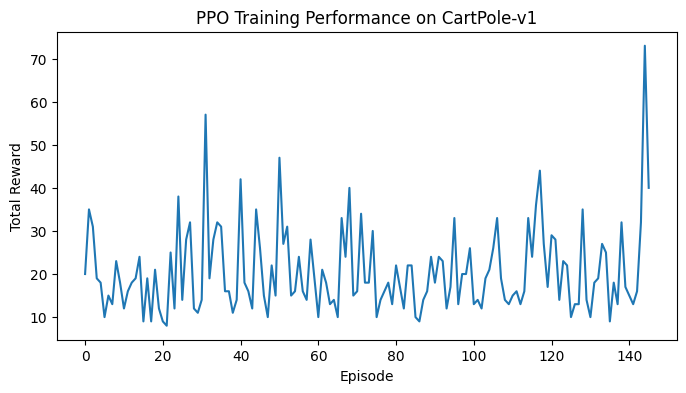

In [61]:
plt.figure(figsize=(8,4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Performance on CartPole-v1")
plt.show()